In [8]:
with open('/content/Exercício Prático 2_ Análise de Desempenho e Limpeza de Dados de E-commerce.md', 'r') as f:
    markdown_content = f.read()

print(markdown_content)

# **Exercício Prático 2: Análise de Desempenho e Limpeza de Dados de E-commerce**

**Objetivo:** Identificar e tratar problemas comuns em dados reais (valores ausentes e duplicados), realizar agregações e criar gráficos de distribuição e comparação.

### **Célula 1: Configuração do Ambiente e Criação dos Dados (Código)**

> *Rode esta célula para gerar o dataset com "imperfeições" simuladas (valores nulos e duplicatas).*

```
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")
np.random.seed(101)

# Gerando dados fictícios de clientes de um e-commerce
n = 200
categorias = ['Eletrônicos', 'Vestuário', 'Casa e Decoração', 'Livros']

dados = {
    'ID_Cliente': np.random.randint(1000, 1050, size=n),
    'Categoria': np.random.choice(categorias, size=n),
    'Valor_Gasto': np.random.normal(loc=250, scale=80, size=n).round(2),
    'Avaliacao_Compra': np.random.choice([1, 2, 3, 4, 5, n

# **Exercício Prático 1.4: Análise de Desempenho e Limpeza de Dados de E-commerce**

**Objetivo:** Identificar e tratar problemas comuns em dados reais (valores ausentes e duplicados), realizar agregações e criar gráficos de distribuição e comparação.

### **Célula 1: Configuração do Ambiente e Criação dos Dados (Código)**

> *Rode esta célula para gerar o dataset com "imperfeições" simuladas (valores nulos e duplicatas).*

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")
np.random.seed(101)

# Gerando dados fictícios de clientes de um e-commerce
n = 200
categorias = ['Eletrônicos', 'Vestuário', 'Casa e Decoração', 'Livros']

dados = {
    'ID_Cliente': np.random.randint(1000, 1050, size=n),
    'Categoria': np.random.choice(categorias, size=n),
    'Valor_Gasto': np.random.normal(loc=250, scale=80, size=n).round(2),
    'Avaliacao_Compra': np.random.choice([1, 2, 3, 4, 5, np.nan], size=n, p=[0.1, 0.1, 0.2, 0.3, 0.2, 0.1]),
    'Idade_Cliente': np.random.randint(18, 65, size=n)
}

df_ecommerce = pd.DataFrame(dados)

# Inserindo algumas linhas duplicadas intencionalmente
df_ecommerce = pd.concat([df_ecommerce, df_ecommerce.iloc[:10]], ignore_index=True)

print("Dataset gerado com sucesso!")
print(f"Total de linhas no dataset: {len(df_ecommerce)}")
df_ecommerce.head()

Dataset gerado com sucesso!
Total de linhas no dataset: 210


,ID_Cliente,Categoria,Valor_Gasto,Avaliacao_Compra,Idade_Cliente
0,1031,Vestuário,236.62,NaN,33
1,1011,Eletrônicos,190.28,4.0,47
2,1017,Eletrônicos,336.59,2.0,35
3,1006,Eletrônicos,307.38,5.0,52
4,1023,Vestuário,170.69,4.0,42


### Solução da Tarefa 1: Limpeza e Preparação dos Dados

In [3]:
# 1. Verifique quantas linhas duplicadas existem no DataFrame e remova-as.
duplicados_antes = df_ecommerce.duplicated().sum()
df_ecommerce.drop_duplicates(inplace=True)
duplicados_depois = df_ecommerce.duplicated().sum()

print(f"Número de linhas duplicadas antes da remoção: {duplicados_antes}")
print(f"Número de linhas duplicadas depois da remoção: {duplicados_depois}")
print(f"Total de linhas no dataset após remoção de duplicados: {len(df_ecommerce)}")

# 2. Identifique quais colunas possuem valores nulos (`NaN`).
valores_nulos = df_ecommerce.isnull().sum()
colunas_com_nulos = valores_nulos[valores_nulos > 0]

print("\nColunas com valores nulos:")
print(colunas_com_nulos)

# 3. Preencha os valores nulos da coluna `Avaliacao_Compra` com a mediana dessa mesma coluna.
mediana_avaliacao = df_ecommerce['Avaliacao_Compra'].median()
df_ecommerce['Avaliacao_Compra'].fillna(mediana_avaliacao, inplace=True)

print(f"\nValores nulos na coluna 'Avaliacao_Compra' preenchidos com a mediana ({mediana_avaliacao}).")
print("Verificação de valores nulos após preenchimento:")
print(df_ecommerce['Avaliacao_Compra'].isnull().sum())

df_ecommerce.head()

Número de linhas duplicadas antes da remoção: 10
Número de linhas duplicadas depois da remoção: 0
Total de linhas no dataset após remoção de duplicados: 200

Colunas com valores nulos:
Avaliacao_Compra    21
dtype: int64

Valores nulos na coluna 'Avaliacao_Compra' preenchidos com a mediana (4.0).
Verificação de valores nulos após preenchimento:
0


/tmp/ipykernel_1592/2989549252.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ecommerce['Avaliacao_Compra'].fillna(mediana_avaliacao, inplace=True)


,ID_Cliente,Categoria,Valor_Gasto,Avaliacao_Compra,Idade_Cliente
0,1031,Vestuário,236.62,4.0,33
1,1011,Eletrônicos,190.28,4.0,47
2,1017,Eletrônicos,336.59,2.0,35
3,1006,Eletrônicos,307.38,5.0,52
4,1023,Vestuário,170.69,4.0,42


### Solução da Tarefa 2: Comparação por Categoria (Gráfico de Boxplot com Seaborn)

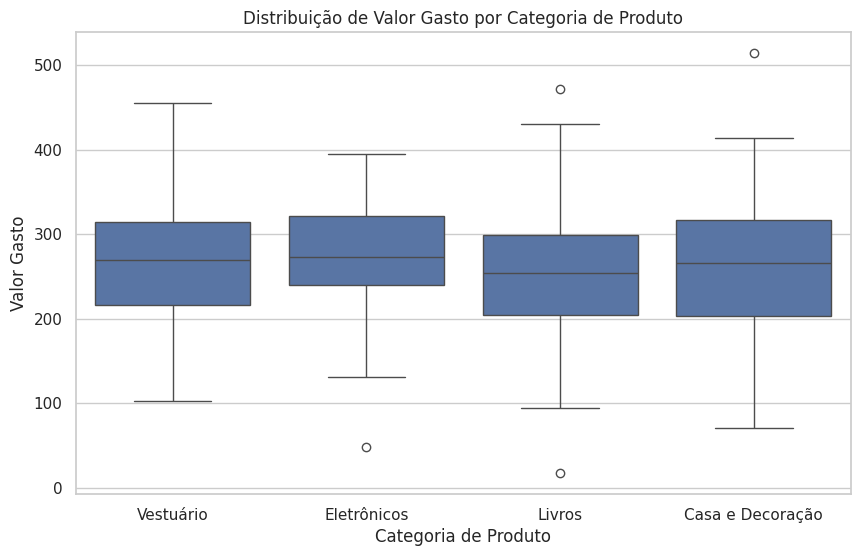


Amplitude Interquartil (IQR) do Valor Gasto por Categoria:
Categoria
Casa e Decoração    114.56
Eletrônicos          81.21
Livros               94.58
Vestuário            98.60
Name: Valor_Gasto, dtype: float64

Desvio Padrão do Valor Gasto por Categoria:
Categoria
Casa e Decoração    88.942519
Eletrônicos         71.303618
Livros              81.135752
Vestuário           77.837054
Name: Valor_Gasto, dtype: float64

Observando o boxplot, a categoria com maior variação e potencial presença de outliers é a que possui uma caixa mais alta e/ou pontos distantes dos 'bigodes'.


In [4]:
# 1. Crie um gráfico de Boxplot usando a biblioteca ‘seaborn’ (‘sns.boxplot’) para comparar a distribuição de `Valor_Gasto` entre as diferentes Categorias de produtos.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Categoria', y='Valor_Gasto', data=df_ecommerce)
plt.title('Distribuição de Valor Gasto por Categoria de Produto')
plt.xlabel('Categoria de Produto')
plt.ylabel('Valor Gasto')
plt.show()

# 2. Identifique qual categoria possui a maior variação ou presença de outliers.
# Podemos observar visualmente do boxplot ou calcular a Amplitude Interquartil (IQR) para cada categoria.
iqr_por_categoria = df_ecommerce.groupby('Categoria')['Valor_Gasto'].agg(lambda x: x.quantile(0.75) - x.quantile(0.25))
print("\nAmplitude Interquartil (IQR) do Valor Gasto por Categoria:")
print(iqr_por_categoria)

std_por_categoria = df_ecommerce.groupby('Categoria')['Valor_Gasto'].std()
print("\nDesvio Padrão do Valor Gasto por Categoria:")
print(std_por_categoria)

print("\nObservando o boxplot, a categoria com maior variação e potencial presença de outliers é a que possui uma caixa mais alta e/ou pontos distantes dos 'bigodes'.")

### Solução da Tarefa 3: Distribuição e Correlação

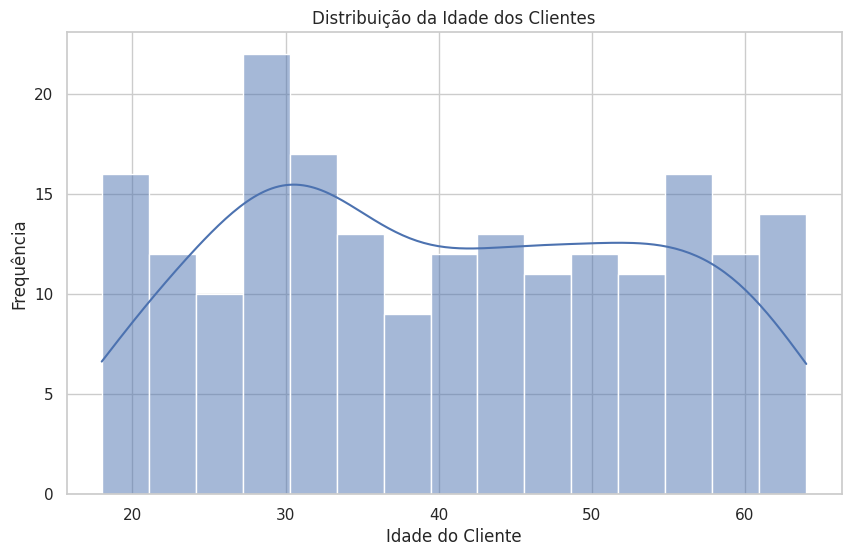

In [5]:
# 1. Crie um gráfico de Histograma com curva de densidade (`sns.histplot` com `kde=True`) para visualizar a distribuição da `Idade_Cliente`.
plt.figure(figsize=(10, 6))
sns.histplot(df_ecommerce['Idade_Cliente'], kde=True, bins=15)

# 2. Adicione título e rótulos adequados aos eixos do gr&#225;fico.
plt.title('Distribuição da Idade dos Clientes')
plt.xlabel('Idade do Cliente')
plt.ylabel('Frequência')
plt.show()

###   **Instruções do Exercício**

Você recebeu a base de dados bruta de transações de um e-commerce. A base contém problemas típicos de coleta: registros duplicados e avaliações não preenchidas.

**Tarefa 1: Limpeza e Preparação dos Dados**  
1. Verifique quantas linhas duplicadas existem no DataFrame e remova-as.  
2. Identifique quais colunas possuem valores nulos (`NaN`).  
3. Preencha os valores nulos da coluna `Avaliacao_Compra` com a mediana dessa mesma coluna.

**Tarefa 2: Comparação por Categoria (Gráfico de Barras / Boxplot com Seaborn)**  
1. Crie um gráfico de Boxplot usando a biblioteca ‘seaborn’ (‘sns.boxplot’) para comparar a distribuição de `Valor_Gasto` entre as diferentes Categorias de produtos.  
2. Identifique qual categoria possui a maior variação ou presença de outliers.

**Tarefa 3: Distribuição e Correlação**  
1. Crie um gráfico de Histograma com curva de densidade (`sns.histplot` com `kde=True`) para visualizar a distribuição da `Idade_Cliente`.  
2. Adicione título e rótulos adequados aos eixos do gráfico.